[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bigdata-com/bigdata-cookbook/blob/main/Sentiment_Pulse/company_sentiment_dashboard.ipynb)

# Company Sentiment Dashboard

**Input:** a single company stock ticker (e.g. `BAC`, `AAPL`, `TSLA`).
**Output:**
1. A **sentiment tearsheet** — a full qualitative research report (executive
   summary, bullish/risk drivers, outlook, ranked evidence) rendered as a
   formatted dashboard card.
2. A **current sentiment snapshot** — the latest daily sentiment score, its
   direction (Bullish / Neutral / Bearish), and how it compares to recent
   history.
3. A **time series chart** of daily sentiment, sentiment pressure, and media
   attention over the lookback window.

All data comes from [Bigdata.com](https://bigdata.com), via two of its
services:
- The **MCP server** (`bigdata_sentiment_tearsheet` tool) for the narrative
  tearsheet — Section 4.
- The **REST Entity Sentiment API** for the daily time series — Sections 5-7.

> **Self-contained notebook.** This notebook has no dependency on any other
> project or codebase — it only needs a Bigdata.com API key and the Python
> packages listed below. Copy this whole `notebook/` folder anywhere and run
> it top to bottom.

**Requirements**
- A Bigdata.com API key (`BIGDATA_API_KEY`). Sign up / get a key at
  [bigdata.com](https://bigdata.com).
- Python packages: `requests`, `pandas`, `matplotlib`, `mcp` (installed below).


## 1. Setup

Install dependencies (skip if already installed) and import the libraries
used throughout the notebook.

In [35]:
# Uncomment to install dependencies in the current kernel:
# %pip install --quiet requests pandas matplotlib mcp

import os
import re
import getpass
from datetime import date, timedelta

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, HTML

from mcp.client.session import ClientSession
from mcp.client.streamable_http import streamablehttp_client

pd.set_option("display.max_columns", None)
print("Setup complete.")

Setup complete.


## 2. Configuration

Set the **one input** this notebook needs: a company ticker. Everything
below derives from `TICKER`.

The API key is read from the `BIGDATA_API_KEY` environment variable. If it
isn't set, you'll be prompted to paste it in (it is not echoed or stored on
disk).

In [36]:
# ---- The only input you need to change ----
TICKER = "TSLA"

# How much sentiment history to chart.
LOOKBACK_DAYS = 180

# ---------------------------------------------

API_BASE = "https://api.bigdata.com"
MCP_BASE = "https://mcp.bigdata.com/"

API_KEY = os.environ.get("BIGDATA_API_KEY") or getpass.getpass(
    "Enter your Bigdata.com API key: "
)

END_DATE = date.today()
START_DATE = END_DATE - timedelta(days=LOOKBACK_DAYS)

HEADERS = {
    "X-API-KEY": API_KEY,
    "Content-Type": "application/json",
    "Accept": "application/json",
}

print(f"Ticker:      {TICKER}")
print(f"Date range:  {START_DATE.isoformat()} -> {END_DATE.isoformat()}")

Ticker:      TSLA
Date range:  2026-03-07 -> 2026-09-03


## 3. Resolve the ticker to a Bigdata.com entity

Bigdata.com identifies companies by a stable `rp_entity_id` rather than by
ticker (tickers are ambiguous across exchanges and change over time). We
resolve the ticker once via the Knowledge Graph **Find companies** endpoint
(`POST /v1/knowledge-graph/companies`), and prefer an exact, publicly-listed
ticker match.

In [37]:
def resolve_ticker(ticker: str) -> dict:
    '''Resolve a ticker to a Bigdata.com Knowledge Graph company record.'''
    resp = requests.post(
        f"{API_BASE}/v1/knowledge-graph/companies",
        headers=HEADERS,
        json={"query": ticker, "types": ["PUBLIC"]},
        timeout=30,
    )
    resp.raise_for_status()
    results = resp.json().get("results", [])
    if not results:
        raise ValueError(f"No company found for ticker {ticker!r}")

    # Prefer an exact ticker match; otherwise fall back to the top match.
    exact = [r for r in results if (r.get("ticker") or "").upper() == ticker.upper()]
    return exact[0] if exact else results[0]


company = resolve_ticker(TICKER)
rp_entity_id = company["id"]

print(f"Resolved '{TICKER}' ->")
print(f"  Name:      {company.get('name')}")
print(f"  Entity ID: {rp_entity_id}")
print(f"  Country:   {company.get('country')}")
print(f"  Sector:    {company.get('sector')}")
print(f"  Website:   {company.get('webpage')}")

Resolved 'TSLA' ->
  Name:      Tesla Inc.
  Entity ID: DD3BB1
  Country:   US
  Sector:    Consumer Goods
  Website:   http://www.tesla.com


## 4. Sentiment tearsheet (Bigdata.com MCP)

Before charting raw numbers, pull the **sentiment tearsheet** — a full
qualitative research report generated by Bigdata.com's `bigdata_sentiment_tearsheet`
tool over its **MCP server** (Model Context Protocol, streamable HTTP). Unlike
the REST time series (Section 5), this is prose + structured tables written by
Bigdata.com's own research pipeline, covering:

- **Quantitative signals** — current / baseline / momentum sentiment and
  media-attention readings, with plain-English interpretations.
- **Executive summary** — a short narrative of what's driving the score.
- **Key drivers** — bullish points and risk/watchlist items.
- **Outlook** — a forward-looking read.
- **Evidence** — the ranked headlines/documents behind the score, with links.

We fetch the raw markdown, parse it into structured fields, then render it as
a formatted dashboard card below.

In [38]:
async def fetch_sentiment_tearsheet(rp_entity_id: str) -> str:
    '''Call the bigdata_sentiment_tearsheet MCP tool and return its raw markdown.'''
    headers = {"x-api-key": API_KEY}
    async with streamablehttp_client(MCP_BASE, headers=headers) as (read_stream, write_stream, _):
        async with ClientSession(read_stream, write_stream) as session:
            await session.initialize()
            result = await session.call_tool(
                "bigdata_sentiment_tearsheet", {"rp_entity_id": rp_entity_id}
            )
            if getattr(result, "isError", False):
                raise RuntimeError(f"bigdata_sentiment_tearsheet error: {result}")
            text = "".join(
                block.text for block in (result.content or []) if getattr(block, "text", None)
            )

    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-zA-Z]*\n", "", text)
        text = re.sub(r"\n```\s*$", "", text)
    return text


tearsheet_md = await fetch_sentiment_tearsheet(rp_entity_id)
print(f"Fetched tearsheet for {company.get('name')}: {len(tearsheet_md)} characters of markdown.")

Fetched tearsheet for Tesla Inc.: 16164 characters of markdown.


Now parse the tearsheet markdown into structured fields — quantitative
metric tables, driver bullets, prose sections, and the evidence table — so we
can lay them out as a dashboard rather than a wall of text.

In [39]:
_NUM_RE = re.compile(r"[-+]?\d+(?:\.\d+)?")


def _to_float(text):
    if text is None:
        return None
    text = text.strip().replace("`", "").replace("%", "")
    m = _NUM_RE.search(text)
    return float(m.group(0)) if m else None


def _direction_from_score(score, label):
    if label:
        low = label.strip().lower()
        for key in ("bullish", "bearish", "neutral"):
            if key in low:
                return key.capitalize()
        if "positive" in low:
            return "Bullish"
        if "negative" in low:
            return "Bearish"
    if score is None:
        return "Neutral"
    if score > 0.5:
        return "Bullish"
    if score < -0.5:
        return "Bearish"
    return "Neutral"


def _split_sections(md, max_level=3):
    sections = []
    current_level, current_heading, buf = 0, "_preamble", []
    for line in md.splitlines():
        m = re.match(r"^(#{1,6})\s+(.*)", line)
        if m and len(m.group(1)) <= max_level:
            sections.append((current_level, current_heading, "\n".join(buf).strip()))
            current_level, current_heading, buf = len(m.group(1)), m.group(2).strip(), []
        else:
            buf.append(line)
    sections.append((current_level, current_heading, "\n".join(buf).strip()))
    return sections


def _strip_code_wrap(s):
    if s is None:
        return None
    s = s.strip()
    if not s:
        return s
    if s.startswith("`") and s.endswith("`") and len(s) >= 2:
        return s[1:-1]
    return s.replace("`", "")


def _parse_metric_table(block):
    rows = []
    for raw in block.splitlines():
        line = raw.strip()
        if not line.startswith("|"):
            continue
        cells = [c.strip() for c in line.strip("|").split("|")]
        if len(cells) < 2:
            continue
        label = cells[0]
        if not label or label.startswith("-") or label.lower() == "metric":
            continue
        raw_value = cells[1] if len(cells) > 1 else None
        interp = cells[2] if len(cells) > 2 else None
        if interp is not None and not interp.strip():
            interp = None
        rows.append({
            "label": label,
            "value": _strip_code_wrap(raw_value),
            "interpretation": interp,
            "numeric": _to_float(raw_value),
        })
    return rows


def _row_lookup(rows, wanted):
    low = wanted.lower().strip()
    for r in rows:
        if r["label"].lower().strip() == low:
            return r
    return None


def _drivers(block):
    bull, risk = [], []
    mode, current = None, []

    def flush():
        nonlocal current
        if not current:
            return
        text = " ".join(s.strip() for s in current if s.strip())
        if mode == "bull":
            bull.append(text)
        elif mode == "risk":
            risk.append(text)
        current = []

    for raw in block.splitlines():
        stripped = raw.strip()
        low = stripped.lower()
        if stripped.startswith("**") and (low.startswith("**bullish") or low.startswith("**bull")):
            flush(); mode = "bull"; continue
        if stripped.startswith("**") and ("risk" in low or "watchlist" in low):
            flush(); mode = "risk"; continue
        if stripped.startswith(("- ", "* ", "• ")):
            flush(); current = [stripped[2:].strip()]
        elif current and stripped:
            current.append(stripped)
        elif not stripped:
            flush()
    flush()
    return bull, risk


def _evidence_rows(block):
    rows = []
    for raw in block.splitlines():
        line = raw.strip()
        if not line.startswith("|"):
            continue
        cells = [c.strip() for c in line.strip("|").split("|")]
        if len(cells) < 2:
            continue
        first = cells[0]
        if not re.fullmatch(r"\d+", first):
            continue
        while len(cells) < 8:
            cells.append("")
        sent_cell = cells[6]
        sentiment = _to_float(sent_cell)
        sent_label = "up" if "▲" in sent_cell else ("down" if "▼" in sent_cell else None)
        link_cell = cells[7]
        link = None
        m = re.search(r"\((https?://[^)\s]+)\)", link_cell)
        if m:
            link = m.group(1)
        elif link_cell.startswith(("http://", "https://")):
            link = link_cell
        rows.append({
            "ranking": int(first),
            "date": cells[1] or None,
            "source": cells[2] or None,
            "headline": cells[3] or None,
            "chunks": int(cells[4]) if cells[4].isdigit() else None,
            "relevance": _to_float(cells[5]),
            "sentiment": sentiment,
            "sentiment_label": sent_label,
            "link": link,
        })
    return rows


def _evidence_count(header, body):
    blob = (header or "") + "\n" + (body or "")
    m = re.search(r"from\s+(\d+)\s+documents", blob, re.IGNORECASE)
    if m:
        return int(m.group(1))
    m = re.search(r"(\d+)\s+documents", blob, re.IGNORECASE)
    return int(m.group(1)) if m else None


def _parse_header(preamble, top_heading):
    out = {
        "title": top_heading, "entity_id": None, "as_of_date": None,
        "powered_by": None, "last_updated": None, "issuer_blurb": None,
    }
    if not preamble:
        return out
    text = preamble
    m = re.search(r"\*\s*Last\s+Updated:\s*([^*\n]+?)\*", text, re.IGNORECASE)
    if m:
        out["last_updated"] = m.group(1).strip()
    for key, target in ((r"Entity\s+ID", "entity_id"), (r"Date", "as_of_date"), (r"Powered\s+by", "powered_by")):
        m = re.search(rf"\*\*{key}:\*\*\s*`?([^`|\n]+?)`?(?=\s*\||\s*\n|\s*$)", text)
        if m:
            out[target] = m.group(1).strip()
    blurb_lines, in_block = [], False
    for line in text.splitlines():
        if line.startswith(">"):
            in_block = True
            blurb_lines.append(line.lstrip(">").strip())
        elif in_block and line.strip() == "":
            break
        elif in_block:
            blurb_lines.append(line.strip())
    if blurb_lines:
        out["issuer_blurb"] = " ".join(s for s in blurb_lines if s)
    return out


def parse_tearsheet(md):
    '''Parse Bigdata.com sentiment-tearsheet markdown into structured fields.'''
    summary = {
        "title": None, "entity_id": None, "as_of_date": None, "powered_by": None,
        "last_updated": None, "issuer_blurb": None, "direction": "Neutral",
        "direction_label": None, "current": None, "baseline": None, "momentum": None,
        "sentiment_rows": [], "attention_rows": [], "executive_summary": None,
        "media_attention_signal": None, "outlook_full": None, "outlook_one_line": None,
        "metrics_reference": None, "bull_drivers": [], "risk_drivers": [],
        "evidence_count": None, "evidence_header": None, "evidence_rows": [],
    }
    if not md:
        return summary

    sections = _split_sections(md)
    preamble = next((body for lvl, _, body in sections if lvl == 0), "")
    h1 = next((h for lvl, h, _ in sections if lvl == 1), None)
    h1_body = next((body for lvl, _, body in sections if lvl == 1), "")
    summary.update(_parse_header(preamble + "\n" + h1_body, h1))

    sentiment_block = attn_block = evidence_block = drivers_block = ""
    outlook_block = exec_block = attn_signal_block = glossary_block = ""
    evidence_header_text = None

    for lvl, heading, body in sections:
        if lvl == 0:
            continue
        lk = heading.lower()
        if "media attention" in lk or lk.startswith("attention"):
            if "signal" in lk:
                attn_signal_block += "\n" + body
            else:
                attn_block += "\n" + body
        elif lk == "sentiment" or lk == "sentiment intelligence" or lk.startswith("sentiment "):
            if lvl == 3 or lk == "sentiment":
                sentiment_block += "\n" + body
        elif "quantitative" in lk or lk.startswith("signals"):
            if not sentiment_block:
                sentiment_block += "\n" + body
        elif "executive summary" in lk:
            exec_block += "\n" + body
        elif "key drivers" in lk or lk == "drivers":
            drivers_block += "\n" + body
        elif lk.startswith("outlook"):
            outlook_block += "\n" + body
        elif lk.startswith("evidence"):
            evidence_block += "\n" + body
            evidence_header_text = heading
        elif lk.startswith("metrics reference") or lk.startswith("metric reference"):
            glossary_block += "\n" + body

    sentiment_rows = _parse_metric_table(sentiment_block)
    attn_rows = _parse_metric_table(attn_block)
    summary["sentiment_rows"] = sentiment_rows
    summary["attention_rows"] = attn_rows

    cur_row = _row_lookup(sentiment_rows, "Current")
    if cur_row:
        summary["current"] = cur_row["numeric"]
    b_row = _row_lookup(sentiment_rows, "Baseline")
    if b_row:
        summary["baseline"] = b_row["numeric"]
    m_row = _row_lookup(sentiment_rows, "Momentum")
    if m_row:
        summary["momentum"] = m_row["numeric"]

    bull, risk = _drivers(drivers_block)
    summary["bull_drivers"], summary["risk_drivers"] = bull, risk

    summary["executive_summary"] = exec_block.strip() or None
    summary["media_attention_signal"] = attn_signal_block.strip() or None
    summary["outlook_full"] = outlook_block.strip() or None
    outlook_lines = [l.strip() for l in outlook_block.splitlines() if l.strip()]
    summary["outlook_one_line"] = outlook_lines[0] if outlook_lines else None
    summary["metrics_reference"] = glossary_block.strip() or None

    ev_rows = _evidence_rows(evidence_block)
    summary["evidence_rows"] = ev_rows
    summary["evidence_header"] = evidence_header_text
    summary["evidence_count"] = _evidence_count(evidence_header_text, evidence_block)

    interp = cur_row["interpretation"] if cur_row else None
    summary["direction_label"] = interp or None
    summary["direction"] = _direction_from_score(summary["current"], interp)

    return summary


tearsheet = parse_tearsheet(tearsheet_md)
print(f"Direction:      {tearsheet['direction']} ({tearsheet['direction_label']})")
print(f"Current score:  {tearsheet['current']}")
print(f"Bull drivers:   {len(tearsheet['bull_drivers'])}")
print(f"Risk drivers:   {len(tearsheet['risk_drivers'])}")
print(f"Evidence rows:  {len(tearsheet['evidence_rows'])}")

Direction:      Neutral (Neutral)
Current score:  -0.05
Bull drivers:   3
Risk drivers:   3
Evidence rows:  50


Finally, render the parsed tearsheet as a formatted dashboard card —
a hero header with the direction badge and current score, side-by-side
quantitative signal tables, executive summary, bullish/risk drivers, outlook,
and the top ranked evidence with clickable source links.

In [40]:
_DIRECTION_COLORS = {
    "Bullish": ("#16a34a", "#dcfce7"),
    "Bearish": ("#dc2626", "#fee2e2"),
    "Neutral": ("#6b7280", "#f3f4f6"),
}


def _escape_html(text):
    '''HTML-escape text pulled from the (externally-sourced) tearsheet before
    it's placed into the page, so a headline or summary can never break the
    layout or inject markup.'''
    if text is None:
        return ""
    return (
        str(text)
        .replace("&", "&amp;")
        .replace("<", "&lt;")
        .replace(">", "&gt;")
        .replace('"', "&quot;")
    )


def _inline_md(text):
    '''Escape HTML, then render the tearsheet's lightweight inline markdown
    (**bold**, *italic*, `code`) so formatting survives instead of showing
    literal asterisks/backticks.'''
    if not text:
        return ""
    out = _escape_html(text)
    out = re.sub(r"\*\*(.+?)\*\*", r"<strong>\1</strong>", out)
    out = re.sub(r"(?<!\*)\*([^*\n]+?)\*(?!\*)", r"<em>\1</em>", out)
    out = re.sub(r"`([^`]+?)`", r'<code style="background:#f3f4f6;padding:1px 4px;border-radius:3px;">\1</code>', out)
    return out


def _metric_table_html(rows, empty_msg):
    if not rows:
        return f'<p style="color:#9ca3af;font-style:italic;margin:4px 0;">{empty_msg}</p>'
    trs = "".join(
        '<tr><td style="padding:4px 10px;font-weight:600;border-bottom:1px solid #f3f4f6;">{}</td>'
        '<td style="padding:4px 10px;font-family:monospace;border-bottom:1px solid #f3f4f6;">{}</td>'
        '<td style="padding:4px 10px;color:#4b5563;border-bottom:1px solid #f3f4f6;">{}</td></tr>'.format(
            _escape_html(r["label"]), _escape_html(r["value"]) or "—", _inline_md(r["interpretation"])
        )
        for r in rows
    )
    return (
        '<table style="border-collapse:collapse;width:100%;font-size:13px;">'
        '<thead><tr style="text-align:left;border-bottom:1px solid #e5e7eb;">'
        '<th style="padding:4px 10px;">Metric</th><th style="padding:4px 10px;">Value</th>'
        '<th style="padding:4px 10px;">Interpretation</th></tr></thead>'
        f'<tbody>{trs}</tbody></table>'
    )


def _bullet_list_html(items, empty_msg, color):
    if not items:
        return f'<p style="color:#9ca3af;font-style:italic;margin:4px 0;">{empty_msg}</p>'
    lis = "".join(f'<li style="margin:4px 0;">{_inline_md(i)}</li>' for i in items)
    return f'<ul style="margin:6px 0;padding-left:18px;color:{color};">{lis}</ul>'


def _evidence_table_html(rows, limit=8):
    if not rows:
        return '<p style="color:#9ca3af;font-style:italic;">No evidence rows parsed.</p>'
    trs = ""
    for r in rows[:limit]:
        sent = r["sentiment"]
        sent_str = f'{sent:+.3f}' if sent is not None else ""
        arrow = " ▲" if r["sentiment_label"] == "up" else (" ▼" if r["sentiment_label"] == "down" else "")
        link = (
            f'<a href="{_escape_html(r["link"])}" target="_blank" rel="noopener">&#8599;</a>'
            if r["link"] else "—"
        )
        trs += (
            '<tr>'
            '<td style="padding:4px 8px;border-bottom:1px solid #f3f4f6;">{}</td>'
            '<td style="padding:4px 8px;border-bottom:1px solid #f3f4f6;white-space:nowrap;">{}</td>'
            '<td style="padding:4px 8px;border-bottom:1px solid #f3f4f6;">{}</td>'
            '<td style="padding:4px 8px;border-bottom:1px solid #f3f4f6;">{}</td>'
            '<td style="padding:4px 8px;border-bottom:1px solid #f3f4f6;font-family:monospace;white-space:nowrap;">{}</td>'
            '<td style="padding:4px 8px;border-bottom:1px solid #f3f4f6;">{}</td>'
            '</tr>'
        ).format(
            r["ranking"], _escape_html(r["date"]), _escape_html(r["source"]),
            _inline_md(r["headline"]), _escape_html(sent_str) + arrow, link,
        )
    footer = ""
    if len(rows) > limit:
        footer = f'<p style="color:#9ca3af;font-size:12px;">Showing top {limit} of {len(rows)} evidence rows.</p>'
    return (
        '<table style="border-collapse:collapse;width:100%;font-size:13px;">'
        '<thead><tr style="text-align:left;border-bottom:1px solid #e5e7eb;">'
        '<th style="padding:4px 8px;">#</th><th style="padding:4px 8px;">Date</th>'
        '<th style="padding:4px 8px;">Source</th><th style="padding:4px 8px;">Headline</th>'
        '<th style="padding:4px 8px;">Sentiment</th><th style="padding:4px 8px;">Link</th></tr></thead>'
        f'<tbody>{trs}</tbody></table>{footer}'
    )


def render_tearsheet(company_name, ticker, ts):
    accent, bg = _DIRECTION_COLORS.get(ts["direction"], _DIRECTION_COLORS["Neutral"])
    cur = ts["current"]
    cur_str = f'{cur:+.3f}' if cur is not None else "—"

    issuer_html = ""
    if ts["issuer_blurb"]:
        issuer_html = (
            '<blockquote style="margin:6px 0 0 0;color:#4b5563;font-size:13px;'
            'border-left:3px solid #e5e7eb;padding-left:10px;">{}</blockquote>'
        ).format(_inline_md(ts["issuer_blurb"]))

    exec_html = ""
    if ts["executive_summary"]:
        exec_html = (
            '<h4 style="margin:18px 0 4px 0;">Executive summary</h4>'
            '<div style="background:#eff6ff;border-radius:6px;padding:10px 14px;font-size:14px;line-height:1.5;">{}</div>'
        ).format(_inline_md(ts["executive_summary"]))

    outlook_text = ts["outlook_full"] or ts["outlook_one_line"]
    outlook_html = ""
    if outlook_text:
        outlook_html = (
            '<h4 style="margin:18px 0 4px 0;">Outlook</h4>'
            '<div style="background:#f9fafb;border-radius:6px;padding:10px 14px;font-size:14px;line-height:1.5;">{}</div>'
        ).format(_inline_md(outlook_text))

    evidence_heading = _escape_html(ts["evidence_header"] or f"Evidence ({ts['evidence_count'] or 0} documents)")
    direction_badge_text = _escape_html(ts["direction_label"] or ts["direction"])
    company_heading = _escape_html(f"{company_name} ({ticker})")
    entity_id_text = _escape_html(ts["entity_id"] or rp_entity_id)
    as_of_text = _escape_html(ts["as_of_date"] or "—")

    html = f'''
    <div style="font-family:-apple-system,'Segoe UI',Roboto,sans-serif;border:1px solid {accent};
                border-radius:10px;padding:18px 22px;max-width:920px;background:white;color:#111827;">
      <div style="display:flex;justify-content:space-between;align-items:flex-start;flex-wrap:wrap;gap:12px;">
        <div>
          <span style="background:{bg};color:{accent};border:1px solid {accent};padding:3px 10px;
                       border-radius:999px;font-weight:600;font-size:12px;">{direction_badge_text}</span>
          <span style="color:#9ca3af;font-size:12px;margin-left:8px;">Entity ID {entity_id_text} &middot; As of {as_of_text}</span>
          <h2 style="margin:8px 0 2px 0;">{company_heading}</h2>
          {issuer_html}
        </div>
        <div style="text-align:center;min-width:120px;">
          <div style="font-size:28px;font-weight:700;color:{accent};">{cur_str}</div>
          <div style="font-size:12px;color:#9ca3af;">Current sentiment</div>
        </div>
      </div>

      <h4 style="margin:18px 0 4px 0;">Quantitative signals</h4>
      <div style="display:flex;gap:24px;flex-wrap:wrap;">
        <div style="flex:1;min-width:280px;">
          <b style="font-size:11px;color:#6b7280;letter-spacing:0.03em;">SENTIMENT</b>
          {_metric_table_html(ts["sentiment_rows"], "No sentiment metrics in this report.")}
        </div>
        <div style="flex:1;min-width:280px;">
          <b style="font-size:11px;color:#6b7280;letter-spacing:0.03em;">MEDIA ATTENTION</b>
          {_metric_table_html(ts["attention_rows"], "No media-attention metrics in this report.")}
        </div>
      </div>

      {exec_html}

      <div style="display:flex;gap:24px;flex-wrap:wrap;margin-top:18px;">
        <div style="flex:1;min-width:280px;">
          <h4 style="margin:0 0 4px 0;color:#16a34a;">Bullish drivers</h4>
          {_bullet_list_html(ts["bull_drivers"], "No bullish drivers detected.", "#166534")}
        </div>
        <div style="flex:1;min-width:280px;">
          <h4 style="margin:0 0 4px 0;color:#d97706;">Risk &amp; watchlist</h4>
          {_bullet_list_html(ts["risk_drivers"], "No risk drivers detected.", "#92400e")}
        </div>
      </div>

      {outlook_html}

      <h4 style="margin:18px 0 4px 0;">{evidence_heading}</h4>
      {_evidence_table_html(ts["evidence_rows"])}
    </div>
    '''
    display(HTML(html))


render_tearsheet(company.get("name"), TICKER, tearsheet)

## 5. Fetch the sentiment time series

The Entity Sentiment endpoint (`POST /v1/entity-sentiment/`) returns one row
per day for the requested window, with three metrics:

| Field | Meaning |
|---|---|
| `daily_sentiment` | Mean sentiment score for the day (roughly -1 = very negative, +1 = very positive). |
| `sentiment_pressure` | How abnormal that day's sentiment intensity is versus the entity's own recent baseline. |
| `abnormal_media_attention` | How abnormal that day's media volume is versus the entity's own recent baseline. |

We load the response into a tidy `pandas.DataFrame` indexed by date.

In [41]:
def fetch_entity_sentiment(rp_entity_id: str, start: date, end: date) -> pd.DataFrame:
    '''Fetch the daily entity-sentiment time series for one company.'''
    resp = requests.post(
        f"{API_BASE}/v1/entity-sentiment/",
        headers=HEADERS,
        json={
            "identifier": {"type": "rp_entity_id", "value": rp_entity_id},
            "timestamp": {"start": start.isoformat(), "end": end.isoformat()},
        },
        timeout=30,
    )
    resp.raise_for_status()
    payload = resp.json()

    # The API nests daily values under results[].values; tolerate a bare list too.
    values = []
    results = payload.get("results")
    if isinstance(results, list):
        for r in results:
            values.extend(r.get("values", []))
    elif isinstance(payload.get("values"), list):
        values = payload["values"]

    if not values:
        raise ValueError(
            f"No sentiment history returned for entity {rp_entity_id} "
            f"between {start} and {end}."
        )

    df = pd.DataFrame(values)
    df["date"] = pd.to_datetime(df["date"].str[:10])
    df = df.set_index("date").sort_index()
    return df[["daily_sentiment", "sentiment_pressure", "abnormal_media_attention"]]


sentiment_df = fetch_entity_sentiment(rp_entity_id, START_DATE, END_DATE)
print(f"Loaded {len(sentiment_df)} daily observations for {company.get('name')}.")
sentiment_df.tail()

Loaded 181 daily observations for Tesla Inc..


,daily_sentiment,sentiment_pressure,abnormal_media_attention
date,,,
2026-08-30,0.005674,0.463869,-0.440242
2026-08-31,0.078717,0.465943,-0.445346
2026-09-01,0.002431,0.431167,-0.447899
2026-09-02,0.100929,0.421174,-0.447502
2026-09-03,0.081864,0.393907,-0.436800


## 6. Current sentiment snapshot

This cell renders the sentiment "headline": the latest available score, its
qualitative direction, and how it compares to the trailing 1-month and
1-quarter averages (momentum).

Direction thresholds used here (adjust to taste):
- `daily_sentiment > 0.15` -> **Bullish**
- `daily_sentiment < -0.15` -> **Bearish**
- otherwise -> **Neutral**

Tesla Inc. (TSLA)  —  as of 2026-09-03
--------------------------------------------------
  Current daily sentiment:   +0.082   [Neutral]
  Sentiment pressure:        +0.394
  Abnormal media attention:  -0.437
  Trailing 1-month average:  +0.075
  Trailing 1-quarter avg.:   +0.072


/var/folders/7c/1g2h3ww906x15rwrst4sl0mc0000gp/T/ipykernel_47048/445031422.py:4: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  trailing_1m = sentiment_df.loc[latest_date - pd.Timedelta(days=30):, "daily_sentiment"].mean()
/var/folders/7c/1g2h3ww906x15rwrst4sl0mc0000gp/T/ipykernel_47048/445031422.py:5: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  trailing_1q = sentiment_df.loc[latest_date - pd.Timedelta(days=90):, "daily_sentiment"].mean()


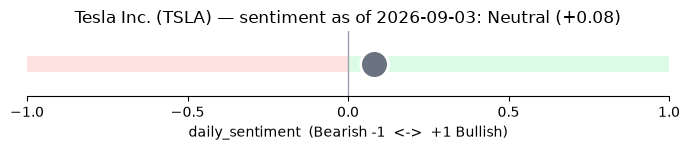

In [42]:
latest = sentiment_df.iloc[-1]
latest_date = sentiment_df.index[-1]

trailing_1m = sentiment_df.loc[latest_date - pd.Timedelta(days=30):, "daily_sentiment"].mean()
trailing_1q = sentiment_df.loc[latest_date - pd.Timedelta(days=90):, "daily_sentiment"].mean()
latest_date = latest_date.date()


def direction_label(score: float) -> str:
    if pd.isna(score):
        return "Unknown"
    if score > 0.15:
        return "Bullish"
    if score < -0.15:
        return "Bearish"
    return "Neutral"


current_score = latest["daily_sentiment"]
direction = direction_label(current_score)

print(f"{company.get('name')} ({TICKER})  —  as of {latest_date}")
print("-" * 50)
print(f"  Current daily sentiment:   {current_score:+.3f}   [{direction}]")
print(f"  Sentiment pressure:        {latest['sentiment_pressure']:+.3f}")
print(f"  Abnormal media attention:  {latest['abnormal_media_attention']:+.3f}")
print(f"  Trailing 1-month average:  {trailing_1m:+.3f}")
print(f"  Trailing 1-quarter avg.:   {trailing_1q:+.3f}")

# --- Sentiment gauge: a horizontal bar from -1 (bearish) to +1 (bullish) ---
fig, ax = plt.subplots(figsize=(7, 1.6))
ax.barh([0], [2], left=-1, color="#e5e7eb", height=0.5, zorder=1)
ax.barh([0], [1], left=0, color="#dcfce7", height=0.5, zorder=1)
ax.barh([0], [1], left=-1, color="#fee2e2", height=0.5, zorder=1)
gauge_color = "#16a34a" if current_score > 0.15 else ("#dc2626" if current_score < -0.15 else "#6b7280")
ax.scatter([current_score], [0], s=400, color=gauge_color, zorder=3, edgecolor="white", linewidth=2)
ax.axvline(0, color="#9ca3af", linewidth=1, zorder=2)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_xlabel("daily_sentiment  (Bearish -1  <->  +1 Bullish)")
ax.set_title(f"{company.get('name')} ({TICKER}) — sentiment as of {latest_date}: {direction} ({current_score:+.2f})")
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Sentiment & media attention time series

The top panel plots the daily sentiment score over the lookback window
(shaded green above zero, red below). The bottom panel plots abnormal media
attention as bars, so spikes in coverage are easy to spot alongside
sentiment swings.

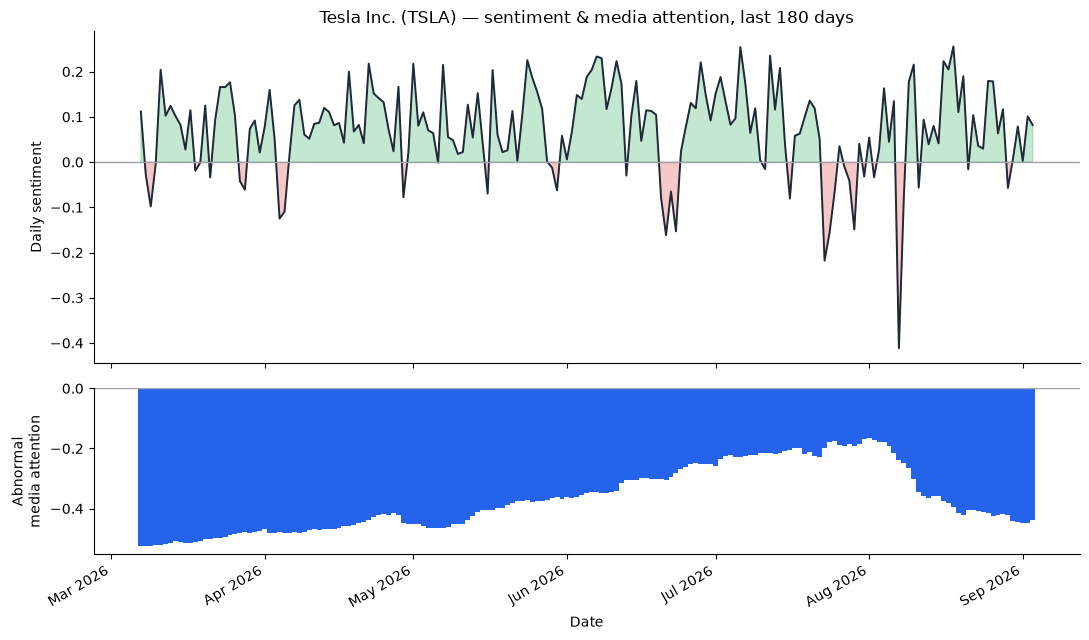

In [43]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(11, 6.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# --- Panel 1: daily sentiment ---
ax1.plot(sentiment_df.index, sentiment_df["daily_sentiment"], color="#1f2937", linewidth=1.4)
ax1.axhline(0, color="#9ca3af", linewidth=1)
ax1.fill_between(
    sentiment_df.index, sentiment_df["daily_sentiment"], 0,
    where=(sentiment_df["daily_sentiment"] >= 0), color="#16a34a", alpha=0.25, interpolate=True,
)
ax1.fill_between(
    sentiment_df.index, sentiment_df["daily_sentiment"], 0,
    where=(sentiment_df["daily_sentiment"] < 0), color="#dc2626", alpha=0.25, interpolate=True,
)
ax1.set_ylabel("Daily sentiment")
ax1.set_title(f"{company.get('name')} ({TICKER}) — sentiment & media attention, last {LOOKBACK_DAYS} days")

# --- Panel 2: abnormal media attention ---
ax2.bar(sentiment_df.index, sentiment_df["abnormal_media_attention"], color="#2563eb", width=1.0)
ax2.axhline(0, color="#9ca3af", linewidth=1)
ax2.set_ylabel("Abnormal\nmedia attention")
ax2.set_xlabel("Date")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

for ax in (ax1, ax2):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Ask questions about the sentiment — traditional RAG (OpenAI)

Everything above already did the hard part of retrieval-augmented generation:
Section 4 fetched the sentiment tearsheet from Bigdata.com. That's just text
pulled from an API — it can be handed straight to an LLM as **context** to
answer free-form questions grounded in that report. (This demo uses the
tearsheet alone; the numeric time series from Section 5 could be folded in
the same way if you want the answers to cite exact daily figures.)

This is deliberately a **traditional RAG** pattern, not an agent:

1. Retrieve once, up front (already done — `tearsheet_md`).
2. Stuff that retrieved text into a single prompt.
3. Call a plain chat-completion model for **one pass of generation** —
   no tool calls, no multi-step planning, no reasoning/"thinking" model
   (e.g. not `o3` or a `gpt-5-thinking`-style model). We use `gpt-5.6-luna`
   so the answer stays grounded in
   the context instead of the model's own background knowledge.

Requires an `OPENAI_API_KEY` (set it the same way as `BIGDATA_API_KEY` in
Section 2, or you'll be prompted below).

In [44]:
from openai import OpenAI

OPENAI_MODEL = "gpt-5.6-luna"  # plain chat-completion model — no extended "thinking"/reasoning step

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY") or getpass.getpass(
    "Enter your OpenAI API key: "
)
openai_client = OpenAI(api_key=OPENAI_API_KEY)

print(f"OpenAI model: {OPENAI_MODEL}")

OpenAI model: gpt-5.6-luna


### 8.1 Build the retrieval context

Wrap the tearsheet markdown already fetched from Bigdata.com in Section 4 as
the RAG context. No new API calls happen here; this step is pure text
assembly.

In [45]:
def build_context(tearsheet_md: str, company_name: str, ticker: str) -> str:
    '''Assemble the RAG context from data already retrieved via Bigdata.com's
    sentiment tearsheet (Section 4) — no extra API calls.'''
    header = f"# Retrieved context for {company_name} ({ticker})\n\n"
    return header + tearsheet_md.strip()


context = build_context(tearsheet_md, company.get("name"), TICKER)
print(f"Context length: {len(context):,} characters (~{len(context) // 4:,} tokens)")

Context length: 16,207 characters (~4,051 tokens)


### 8.2 Single-pass grounded Q&A

`ask_about_sentiment` sends the context and a question to OpenAI in one
request and returns one answer — the whole "RAG" here is prompt assembly
plus a single `chat.completions.create` call, no agent loop.

In [46]:
SYSTEM_PROMPT = (
    "You are a sell-side research assistant. Answer the user's question about the "
    "company using ONLY the CONTEXT below, which was retrieved from Bigdata.com's "
    "sentiment tearsheet API. This is a traditional retrieval-"
    "augmented-generation setup: the context was fetched once, up front, and you do a "
    "single pass of generation over it — do not invent facts or use outside knowledge. "
    "If the context doesn't contain the answer, say so explicitly. When you reference a "
    "specific news item from the evidence table, cite its [#] ranking."
)


def ask_about_sentiment(question: str, context: str, model: str = OPENAI_MODEL) -> str:
    '''Traditional (non-reasoning) RAG: stuff the retrieved context into the prompt and
    generate one grounded answer with a plain chat-completion model. Some models (including
    gpt-5.6-luna) only support the default temperature, so it is not set here.'''
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"CONTEXT:\n{context}\n\nQUESTION: {question}"},
        ],
    )
    return response.choices[0].message.content.strip()

In [47]:
def render_rag_answer(question: str, answer: str, model: str = OPENAI_MODEL) -> None:
    '''Render one grounded Q&A pair as a dashboard-style HTML card.'''
    display(HTML(f'''
    <div style="font-family:-apple-system,'Segoe UI',Roboto,sans-serif;border:1px solid #2563eb;
                border-radius:10px;padding:16px 20px;max-width:920px;background:#eff6ff;color:#111827;
                margin-bottom:12px;">
      <div style="font-size:12px;color:#2563eb;font-weight:600;letter-spacing:0.03em;">
        RAG ANSWER &middot; {_escape_html(model)} &middot; grounded in the Bigdata.com sentiment tearsheet
      </div>
      <p style="margin:6px 0 10px 0;font-style:italic;color:#4b5563;">{_escape_html(question)}</p>
      <div style="line-height:1.5;">{_inline_md(answer)}</div>
    </div>
    '''))

### 8.3 Try it

Change `QUESTION` to anything about this company's sentiment and re-run —
the answer is grounded in the tearsheet and snapshot fetched above, nothing
else.

In [48]:
QUESTION = f"What is driving {company.get('name')}'s sentiment right now, and what's the biggest risk to watch?"

answer = ask_about_sentiment(QUESTION, context)
render_rag_answer(QUESTION, answer)

In [49]:
# A few more sample questions over the same context — each is an independent,
# single-pass call (no memory of previous answers, by design).
SAMPLE_QUESTIONS = [
    "Is the market more bullish or bearish on this company right now?",
    "What would need to happen for the sentiment outlook to flip?",
]

for q in SAMPLE_QUESTIONS:
    a = ask_about_sentiment(q, context)
    render_rag_answer(q, a)

## Notes

- **Tearsheet (MCP) vs. time series (REST).** The tearsheet in Section 4 is
  a point-in-time narrative report — regenerated on each call, and best used
  for "what's the story right now" context. The time series in Sections 5-7
  is a pure numeric feed — best used for trend-spotting and charting over a
  window. They're two different Bigdata.com services (MCP vs. REST) and can
  disagree slightly in exact wording/thresholds; treat the tearsheet as the
  qualitative read and the time series as the quantitative one.
- **What "sentiment" means here.** `daily_sentiment` is not a stock-price
  prediction — it's a text-derived signal summarizing how positively or
  negatively a company is being discussed in news, filings, and other
  sources on a given day. Treat it as one input among many, not a trading
  signal on its own.
- **`sentiment_pressure` vs. `abnormal_media_attention`.** Pressure captures
  whether *today's* sentiment is unusually strong relative to the entity's
  own history; attention captures whether *coverage volume* is unusually
  high. A spike in both together (in either direction) is usually the most
  actionable combination — it means something happened, and the tone of
  coverage was extreme.
- **Data lag.** Sentiment is computed from published text, so very recent
  days may be incomplete until sources finish indexing.
- **Reusing this notebook.** To analyze a different company, change only the
  `TICKER` value in Section 2 and re-run all cells. No other code needs to
  change.
- **Section 8 is traditional RAG, not an agent.** The tearsheet is
  retrieved once (Section 4); Section 8 stuffs that
  text into a single prompt and calls a plain chat-completion model
  (`gpt-5.6-luna`) for one grounded generation pass —
  no reasoning model, no tool-calling loop, no multi-step agent.
- **Data source.** All data in this notebook is sourced from
  [Bigdata.com](https://bigdata.com)'s Sentiment Tearsheet (MCP), Entity
  Sentiment API (REST), and Knowledge Graph. See their
  [API docs](https://docs.bigdata.com) for full field definitions and rate
  limits.
